#### Land Class Interactions: Deciduous Woodland (DW) Net Change Diverging Bar Chart
- Net change in absolute DW area resulting from land class transfers between 1990 and 2024.

In [1]:
# Importing the required packages
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Importing localised file directory
project_root = Path(os.environ['marsh_tit_project'])

# Importing the required datasets
lcc = pd.read_csv(project_root/'ukceh'/'custom'/'lcg_england_wales_25m_grouped_labelled.csv')

#### Cleaning the imported DataFrame
- Filtering Land Change Classification (lcc) DataFrame to extract all records of DW in the 'Classification' column (2024) or the 'Reference' column (1990).
- Converting area units from m^2 to km^2.

In [2]:
# Applying the filter
lcc_filtered = (
    lcc[(lcc['Reference']=='deciduous') 
    | (lcc['Classification']=='deciduous')]
)

# Converting units from m^2 to km^2
lcc_filtered['area_km2'] = lcc_filtered['Area [metre^2]']/(1000*1000)

# Removing redundant columns
lcc_deciduous = lcc_filtered.drop(columns=['RasterValue', 
                                             'PixelSum', 
                                             'Area [metre^2]'])

# Removing row where both 'Classification' and 'Reference' are 'deciduous'
lcc_deciduous = (
    lcc_deciduous[~((lcc['Reference']=='deciduous') 
                      & (lcc['Classification']=='deciduous'))]
    .reset_index(drop=True)
)

C:\Users\amman\AppData\Local\Temp\ipykernel_18212\4181009505.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lcc_filtered['area_km2'] = lcc_filtered['Area [metre^2]']/(1000*1000)
C:\Users\amman\AppData\Local\Temp\ipykernel_18212\4181009505.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  lcc_deciduous[~((lcc['Reference']=='deciduous')


#### Computing net change in DW area by land class
- Subtracting losses from gains by land class

In [3]:
# First, creating a new DataFrame 'net_change' to store net change results
net_change=lcc_deciduous[:6][['Reference']] # copying land classes to new DataFrame
net_change['area_net_km2'] = 0 # creating new column to store net change results

# First 6 rows in 'lcc_deciduous' DataFrame contain gains, last 6 losses. Subtracting 
# gains from losses and assigning to 'net_change' dataframe
for i in np.arange(0,6,1):
    net_change.loc[i,'area_net_km2'] = (
        (lcc_deciduous.iloc[i, 2] - lcc_deciduous.iloc[i+6, 2])
    )

C:\Users\amman\AppData\Local\Temp\ipykernel_18212\2862551738.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '183.89249999999993' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  net_change.loc[i,'area_net_km2'] = (


#### Preparing the DataFrame for Visualisation 

In [4]:
# Arranging the values in descending order
net_change = net_change.sort_values('area_net_km2', ascending=False)

# Capitalising the First letter in each string
net_change['Reference'] = net_change['Reference'].str.capitalize()

#### Adding green-red colour gradient bar chart
- Green to show biggest net increases, red to show biggest net decreases

In [5]:
# Importing colour map and visualisation packages
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import LinearSegmentedColormap

# Defining the min and max values for colour mapping
normalise=TwoSlopeNorm(vmin=-net_change['area_net_km2'].max(),
                  vcenter=0,
                  vmax=net_change['area_net_km2'].max())

# Defining the colours to be mapped
rwg = LinearSegmentedColormap.from_list(
    'red_white_green',
    ['red', 'white', 'green']
)

# Generating colour gradient using colours and normalised values
col_grad=[]
for values in net_change['area_net_km2']:
    col_grad.append(rwg(normalise(values)))

#### Plotting the bar chart

C:\Users\amman\AppData\Local\Temp\ipykernel_18212\258776133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  net_change_bar = sns.barplot(data=net_change,


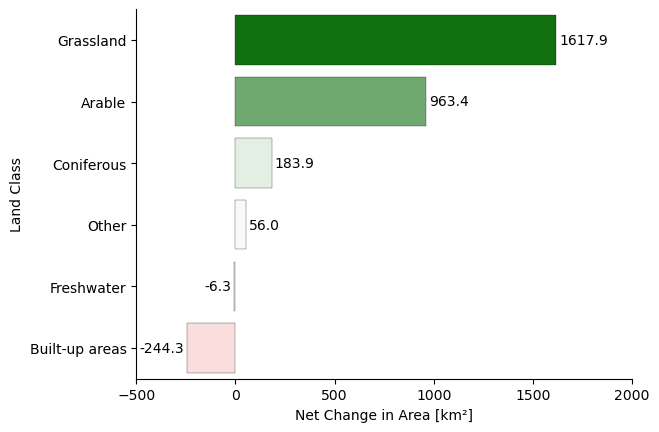

In [6]:
plt.clf()
net_change_bar = sns.barplot(data=net_change,
                       x='area_net_km2',
                       y='Reference',
                       palette=col_grad, # colour gradient
                      edgecolor='black',
                      linewidth=0.2)

net_change_bar.set_ylabel('Land Class')
net_change_bar.set_xlabel('Net Change in Area [km²]')
net_change_bar.set_xlim(-500, 2000)

sns.despine(top=True,
            right=True) # removes top and right border of figure

for container in net_change_bar.containers:
    net_change_bar.bar_label(container,
                       fmt='%.1f', # 1 decimal place
                   padding=2) # spacing of label to bar

# Exporting figure
plt.savefig(project_root/'gis_marsh_tit'/'project_pics'/'land_change_class_bar', 
            dpi=300, 
            bbox_inches='tight')
plt.show()